In [1]:
from pathlib import Path
import pandas as pd
import re


import warnings
warnings.filterwarnings('ignore')

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedShuffleSplit, StratifiedKFold, GridSearchCV
from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix,
                             roc_auc_score, precision_recall_curve, ConfusionMatrixDisplay)
import joblib


import joblib, os
import numpy as np
import pandas as pd
import torch

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau

import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
import shap
import phate
from scipy.stats import spearmanr

# Set reproducibility seeds
np.random.seed(42)
torch.manual_seed(42)
import random
random.seed(42)

In [2]:
# Load the raw tables
DATA_DIR = Path("/def-singhm/masoudk")
RNASEQ_PATH = 'rnaseq_data.tsv'
META_PATH = 'meta_data.tsv'

# Load metadata normally
meta_df = pd.read_csv(META_PATH, sep="\t")

# Read first row for gene names
header_df = pd.read_csv(RNASEQ_PATH, sep="\t", header=None, nrows=1, dtype=str)
gene_names = header_df.iloc[0, :].tolist()

# Read data rows (skip header)
rnaseq_df = pd.read_csv(RNASEQ_PATH, sep="\t", header=None, skiprows=1, dtype=str, engine='python', on_bad_lines='warn')

# Pad/truncate to match header length
if rnaseq_df.shape[1] > len(gene_names):
    rnaseq_df = rnaseq_df.iloc[:, :len(gene_names)]
elif rnaseq_df.shape[1] < len(gene_names):
    for i in range(len(gene_names) - rnaseq_df.shape[1]):
        rnaseq_df[len(rnaseq_df.columns)] = None

rnaseq_df.columns = gene_names

# Rename first column to "sample_id"
rnaseq_df = rnaseq_df.rename(columns={gene_names[0]: 'sample_id'})

print(f"RNA-seq shape: {rnaseq_df.shape}")

RNA-seq shape: (6606, 19311)


In [3]:
sorted(meta_df["histological_grade"].dropna().unique())

['G1',
 'G2',
 'G3',
 'G4',
 'GB',
 'GX',
 'High Grade',
 'Low Grade',
 '[Discrepancy]',
 '[Unknown]']

In [4]:
TCGA_ID_PATTERN = re.compile(r"TCGA-[A-Z0-9]+-[A-Z0-9]+-\d+")


def _clean_meta(df: pd.DataFrame) -> pd.DataFrame:
    meta = df.copy()
    meta.columns = (
        meta.columns.astype(str)
        .str.strip()
        .str.strip('"')
        .str.lower()
        .str.replace(" ", "_", regex=False)
    )
    
    if 'sample' in meta.columns:
        meta['patient_id'] = meta['sample'].astype(str).str.strip().str.replace('"', '')

    
    meta = meta.dropna(subset=['patient_id']).drop_duplicates('patient_id')

    if "histological_grade" in meta.columns:
        meta["histological_grade"] = (
            meta["histological_grade"].astype(str).str.strip().str.upper().replace({"": pd.NA})
        )

    return meta


def _clean_rnaseq(df: pd.DataFrame) -> pd.DataFrame:
    """
    RNA-seq data structure:
    - Header row: gene names (19311 fields)
    - Data rows: TCGA sample ID in col 1, then 19310 expression values
    """
    # Extract gene names from header
    gene_names = df.columns.astype(str).str.strip().str.replace('"', '')
    
    # Extract sample IDs from first column (no normalization)
    sample_ids = df.iloc[:, 0].astype(str).str.strip().str.replace('"', '')
    
    # Extract expression data: columns 2 onwards
    expr_data = df.iloc[:, 1:].copy()
    expr_data.columns = gene_names[:len(expr_data.columns)]
    expr_data = expr_data.apply(pd.to_numeric, errors="coerce")
    
    # Create dataframe with sample_id and gene expressions
    rna_clean = pd.concat([
        sample_ids.reset_index(drop=True),
        expr_data.reset_index(drop=True)
    ], axis=1)
    
    rna_clean.columns = ['patient_id'] + list(expr_data.columns)
    
    # Remove any empty sample IDs
    rna_clean = rna_clean[rna_clean['patient_id'].str.len() > 0].dropna(subset=['patient_id'])
    
    rna_clean = rna_clean.set_index('patient_id')
    
    # Handle duplicate patients by averaging
    rna_final = rna_clean.groupby(level=0).mean()
    rna_final = rna_final.T  # genes x patients
    rna_final['gene_id'] = rna_final.index
    rna_final = rna_final[['gene_id'] + [c for c in rna_final.columns if c != 'gene_id']]
    rna_final = rna_final.reset_index(drop=True)
    
    return rna_final


clean_meta_df = _clean_meta(meta_df)
clean_rnaseq_df = _clean_rnaseq(rnaseq_df)

rnaseq_patient_ids = set(clean_rnaseq_df.columns) - {"gene_id"}
matched_patient_ids = sorted(set(clean_meta_df["patient_id"]) & rnaseq_patient_ids)

clean_meta_df = clean_meta_df[clean_meta_df["patient_id"].isin(matched_patient_ids)].reset_index(drop=True)
clean_rnaseq_df = clean_rnaseq_df[["gene_id"] + matched_patient_ids]

print(f"Matched {len(matched_patient_ids)} patients across both tables")
print(f"Metadata: {len(clean_meta_df)} rows")
print(f"RNA-seq: {len(clean_rnaseq_df)} genes × {len(matched_patient_ids)} samples")
clean_meta_df.head()

Matched 6606 patients across both tables
Metadata: 6606 rows
RNA-seq: 19310 genes × 6606 samples


,meta_data.tsv,sample_type,project_id,rnaseqid,mutid,sample,x_patient,cancer.type.abbreviation,age_at_initial_pathologic_diagnosis,gender,...,os.time,dss,dss.time,dfi,dfi.time,pfi,pfi.time,redaction,x_primary_disease,patient_id
0,1.0,Primary Tumor,TCGA-GBM,TCGA-02-0047-01A,TCGA-02-0047-01,TCGA-02-0047-01,TCGA-02-0047,GBM,78.0,MALE,...,448.0,1.0,448.0,NaN,NaN,1.0,57.0,NaN,glioblastoma multiforme,TCGA-02-0047-01
1,1.0,Primary Tumor,TCGA-GBM,TCGA-02-0055-01A,TCGA-02-0055-01,TCGA-02-0055-01,TCGA-02-0055,GBM,62.0,FEMALE,...,76.0,1.0,76.0,NaN,NaN,1.0,6.0,NaN,glioblastoma multiforme,TCGA-02-0055-01
2,1.0,Primary Tumor,TCGA-GBM,TCGA-02-2483-01A,TCGA-02-2483-01,TCGA-02-2483-01,TCGA-02-2483,GBM,43.0,MALE,...,466.0,0.0,466.0,NaN,NaN,0.0,466.0,NaN,glioblastoma multiforme,TCGA-02-2483-01
3,1.0,Primary Tumor,TCGA-GBM,TCGA-02-2485-01A,TCGA-02-2485-01,TCGA-02-2485-01,TCGA-02-2485,GBM,53.0,MALE,...,470.0,0.0,470.0,NaN,NaN,1.0,186.0,NaN,glioblastoma multiforme,TCGA-02-2485-01
4,1.0,Primary Tumor,TCGA-GBM,TCGA-02-2486-01A,TCGA-02-2486-01,TCGA-02-2486-01,TCGA-02-2486,GBM,64.0,MALE,...,618.0,1.0,618.0,NaN,NaN,1.0,618.0,NaN,glioblastoma multiforme,TCGA-02-2486-01


In [6]:
meta_test = meta_df.copy()
cols_lower = (
    meta_test.columns.astype(str)
    .str.strip()
    .str.strip('"')
    .str.lower()
    .str.replace(" ", "_", regex=False)
)
meta_test.columns = cols_lower

id_candidates = ['sample', 'x_patient', 'rnaseqid', 'sample_type_id', 'mutid']

def _normalize_patient_id(val):
    if pd.isna(val):
        return pd.NA
    s = str(val).strip().replace('"', '')
    return s if s else pd.NA

def _select_patient_id_test(row):
    for col in id_candidates:
        val = row.get(col)
        normalized = _normalize_patient_id(val)
        print(f"    {col}: {val} -> {normalized}")
        if not pd.isna(normalized):
            return normalized
    return pd.NA

In [7]:
print("Meta patient_id):")
print(clean_meta_df['patient_id'].head().tolist())

print("\nRNA-seq patient_id:")
print(list(rnaseq_patient_ids)[:5])

print(f"\nMeta unique count: {len(set(clean_meta_df['patient_id']))}")
print(f"RNA-seq unique count: {len(rnaseq_patient_ids)}")

print("\nIntersection:")
intersection = set(clean_meta_df["patient_id"]) & rnaseq_patient_ids
print(f"Matched: {len(intersection)}")

Meta patient_id):
['TCGA-02-0047-01', 'TCGA-02-0055-01', 'TCGA-02-2483-01', 'TCGA-02-2485-01', 'TCGA-02-2486-01']

RNA-seq patient_id:
['TCGA-AB-2823-03', 'TCGA-EB-A5FP-01', 'TCGA-BP-4965-01', 'TCGA-A7-A3RF-01', 'TCGA-2G-AAL5-01']

Meta unique count: 6606
RNA-seq unique count: 6606

Intersection:
Matched: 6606


In [9]:
print("=== DATASET BEFORE LABELING ===")
print(f"Metadata shape: {clean_meta_df.shape}")
print(f"RNA-seq shape: {clean_rnaseq_df.shape}")

# Map cancer grades to binary risk labels
# low risk: G1 / LOW GRADE
# high risk: G3 / G4 / HIGH GRADE
# (G2 and unknowns are excluded)
low_risk_grades = {'G1', 'G2', 'LOW GRADE'}
high_risk_grades = {'G3', 'G4', 'HIGH GRADE'}

def grade_to_risk_label(grade):
    """Map histological grade to binary risk label."""
    if pd.isna(grade):
        return pd.NA
    grade_str = str(grade).strip().upper()
    if grade_str in low_risk_grades:
        return 0  # Low risk
    elif grade_str in high_risk_grades:
        return 1  # High risk
    else:
        return pd.NA  # Unknown

clean_meta_df['risk_label'] = clean_meta_df['histological_grade'].apply(grade_to_risk_label)

# Filter to only samples with valid risk labels
valid_idx = clean_meta_df['risk_label'].notna()
labeled_meta_df = clean_meta_df[valid_idx].reset_index(drop=True)

# Filter RNA-seq to match
valid_patient_ids = set(labeled_meta_df['patient_id'])
labeled_rnaseq_df = clean_rnaseq_df[['gene_id'] + sorted([p for p in clean_rnaseq_df.columns if p in valid_patient_ids])].reset_index(drop=True)

print("\n=== DATASET AFTER LABELING ===")
print(f"Metadata shape: {labeled_meta_df.shape}")
print(f"RNA-seq shape: {labeled_rnaseq_df.shape}")
print(f"\nRisk label distribution:")
print(labeled_meta_df['risk_label'].value_counts().sort_index())
print(f"  0 (Low risk):  {(labeled_meta_df['risk_label'] == 0).sum()}")
print(f"  1 (High risk): {(labeled_meta_df['risk_label'] == 1).sum()}")

=== DATASET BEFORE LABELING ===
Metadata shape: (6606, 41)
RNA-seq shape: (19310, 6607)

=== DATASET AFTER LABELING ===
Metadata shape: (2662, 42)
RNA-seq shape: (19310, 2663)

Risk label distribution:
risk_label
0    1117
1    1545
Name: count, dtype: int64
  0 (Low risk):  1117
  1 (High risk): 1545


labeled_meta_df shape: (2662, 42)
Columns: ['meta_data.tsv', 'sample_type', 'project_id', 'rnaseqid', 'mutid', 'sample', 'x_patient', 'cancer.type.abbreviation', 'age_at_initial_pathologic_diagnosis', 'gender', 'race', 'ajcc_pathologic_tumor_stage', 'clinical_stage', 'histological_type', 'histological_grade', 'initial_pathologic_dx_year', 'menopause_status', 'birth_days_to', 'vital_status', 'tumor_status', 'last_contact_days_to', 'death_days_to', 'cause_of_death', 'new_tumor_event_type', 'new_tumor_event_site', 'new_tumor_event_site_other', 'new_tumor_event_dx_days_to', 'treatment_outcome_first_course', 'margin_status', 'residual_tumor', 'os', 'os.time', 'dss', 'dss.time', 'dfi', 'dfi.time', 'pfi', 'pfi.time', 'redaction', 'x_primary_disease', 'patient_id', 'risk_label']
                        x_primary_disease  total_samples positive_count  \
0            bladder urothelial carcinoma            204            183   
1                brain lower grade glioma            182            

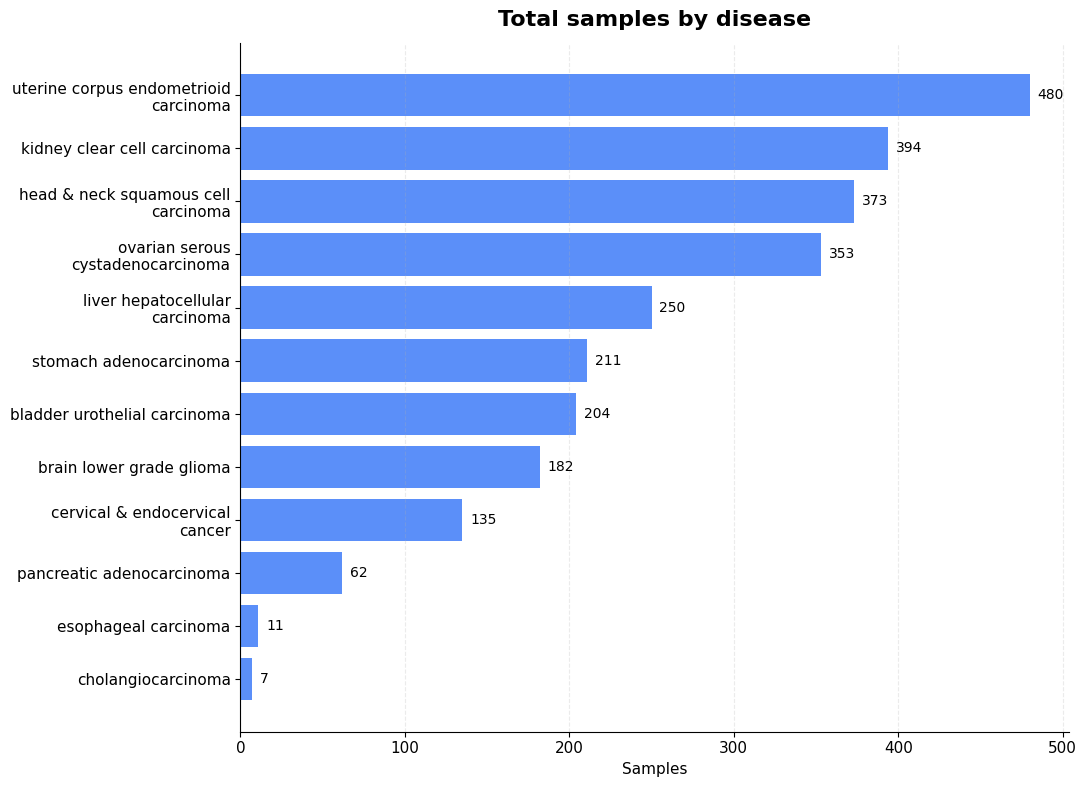

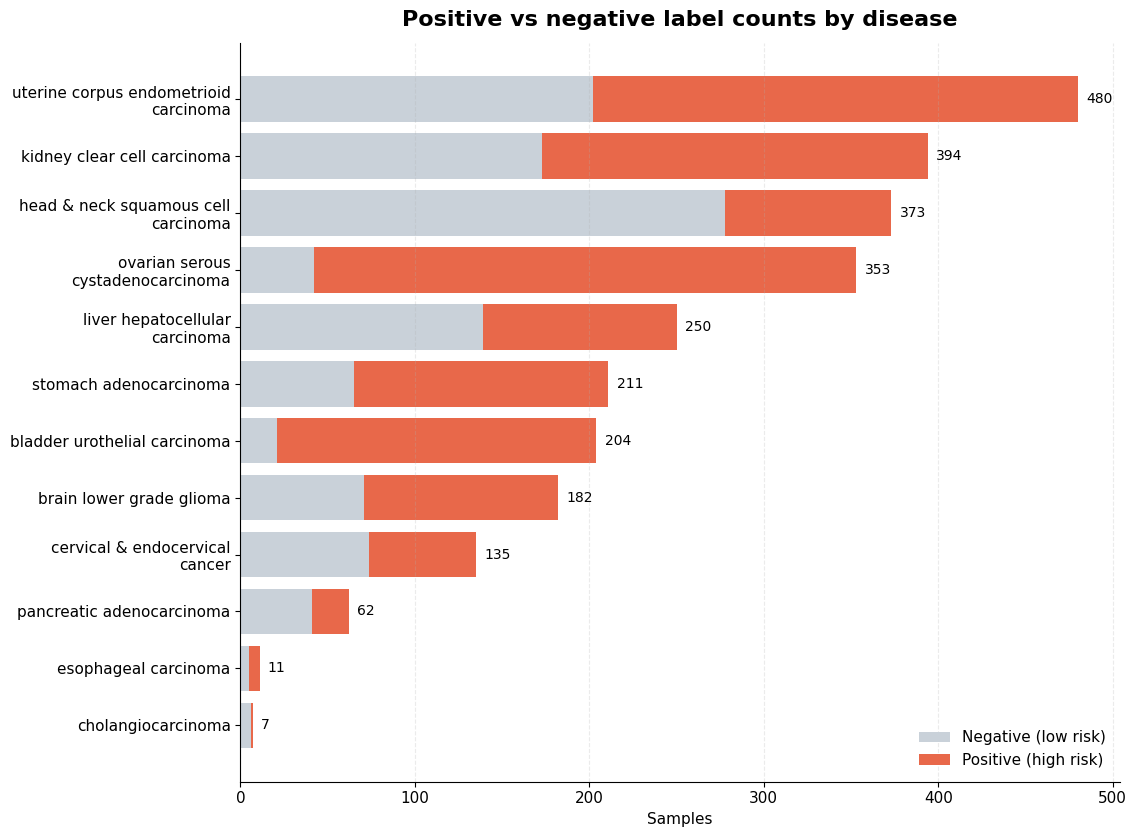

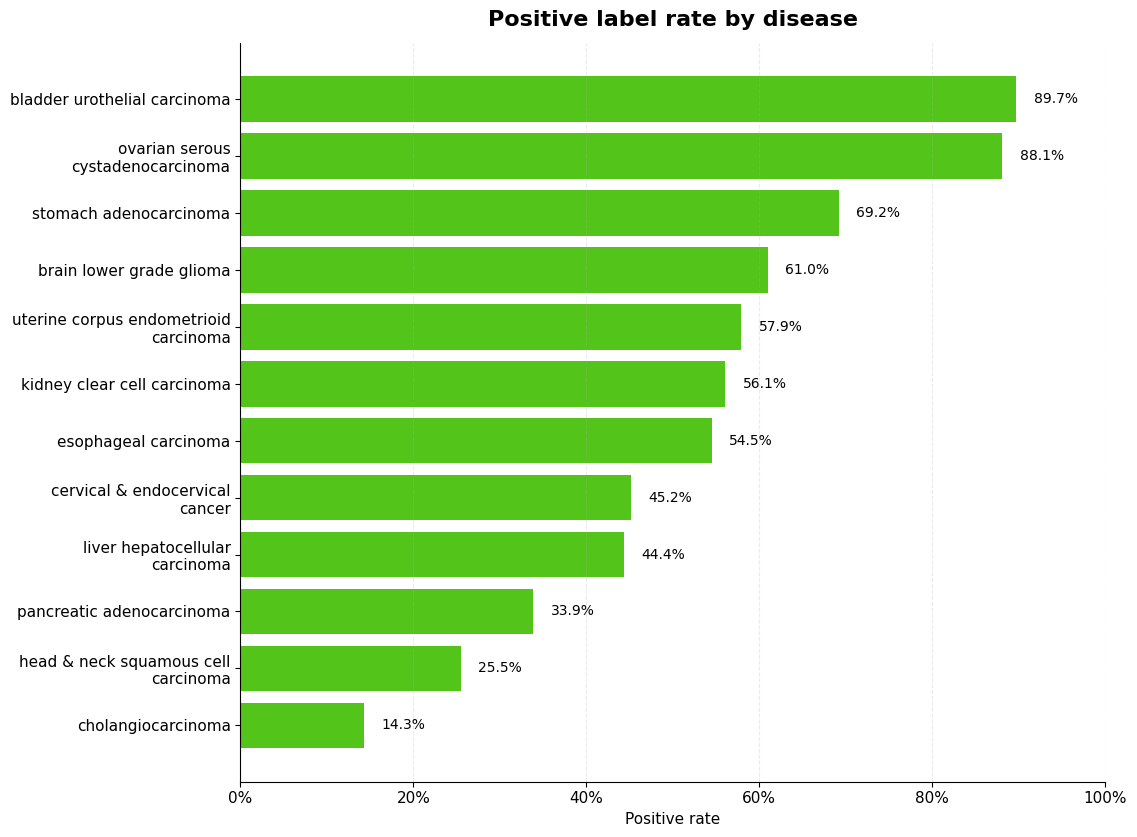

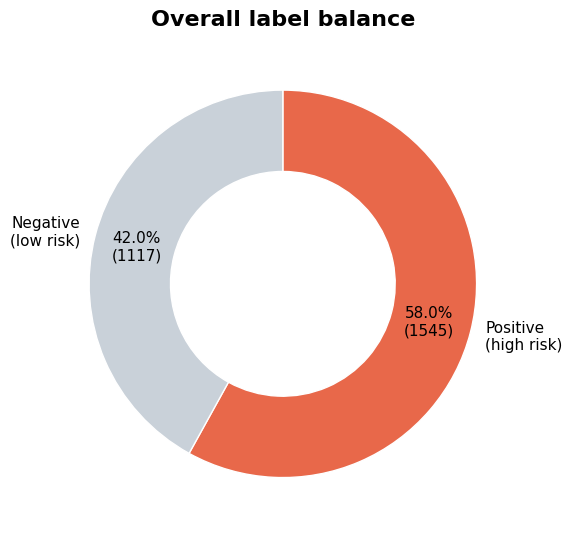

Saved figures to: /project/6068243/masoudk/Baseline/grade_label_figures


In [ ]:
from pathlib import Path
import textwrap

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# Build disease level summary variables
print("labeled_meta_df shape:", labeled_meta_df.shape)
print("Columns:", labeled_meta_df.columns.tolist())

summary = (
    labeled_meta_df
    .groupby("x_primary_disease")["risk_label"]
    .agg(
        total_samples="count",
        positive_count="sum"
    )
    .reset_index()
)

# negatives = total - positives
summary["negative_count"] = summary["total_samples"] - summary["positive_count"]

# rates
summary["positive_rate"] = summary["positive_count"] / summary["total_samples"]
summary["negative_rate"] = summary["negative_count"] / summary["total_samples"]

# sort by cancer type
summary = summary.sort_values("x_primary_disease").reset_index(drop=True)

print(summary)

# Output folder
fig_dir = Path("grade_label_figures")
fig_dir.mkdir(parents=True, exist_ok=True)

plot_df = summary.sort_values("total_samples", ascending=True).copy()
plot_df["wrapped_disease"] = plot_df["x_primary_disease"].apply(
    lambda s: "\n".join(textwrap.wrap(str(s), width=28))
)

max_total = summary["total_samples"].max()

# Plot 1: total samples by disease
plt.rcParams.update({"font.size": 11})

fig, ax = plt.subplots(figsize=(11, 8))
ax.barh(plot_df["wrapped_disease"], plot_df["total_samples"], color="#5B8FF9")
ax.set_title("Total samples by disease", fontsize=16, pad=12, weight="bold")
ax.set_xlabel("Samples")
ax.set_ylabel("")
ax.grid(axis="x", linestyle="--", alpha=0.25)

for i, v in enumerate(plot_df["total_samples"]):
    ax.text(v + max_total * 0.01, i, str(v), va="center", fontsize=10)

ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()

for ext in ["png", "svg"]:
    fig.savefig(
        fig_dir / f"01_total_samples_by_disease.{ext}",
        dpi=300 if ext == "png" else None,
        bbox_inches="tight"
    )

plt.show()
plt.close(fig)

# Plot 2: stacked positive / negative counts by disease
fig, ax = plt.subplots(figsize=(11.5, 8.5))

ax.barh(
    plot_df["wrapped_disease"],
    plot_df["negative_count"],
    color="#C9D1D9",
    label="Negative (low risk)"
)

ax.barh(
    plot_df["wrapped_disease"],
    plot_df["positive_count"],
    left=plot_df["negative_count"],
    color="#E8684A",
    label="Positive (high risk)"
)

ax.set_title("Positive vs negative label counts by disease", fontsize=16, pad=12, weight="bold")
ax.set_xlabel("Samples")
ax.set_ylabel("")
ax.grid(axis="x", linestyle="--", alpha=0.25)
ax.legend(frameon=False, loc="lower right")

for i, total in enumerate(plot_df["total_samples"]):
    ax.text(total + max_total * 0.01, i, str(total), va="center", fontsize=10)

ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()

for ext in ["png", "svg"]:
    fig.savefig(
        fig_dir / f"02_positive_negative_counts_by_disease.{ext}",
        dpi=300 if ext == "png" else None,
        bbox_inches="tight"
    )

plt.show()
plt.close(fig)

# Plot 3: positive rate by disease
rate_df = summary.sort_values("positive_rate", ascending=True).copy()
rate_df["wrapped_disease"] = rate_df["x_primary_disease"].apply(
    lambda s: "\n".join(textwrap.wrap(str(s), width=28))
)

fig, ax = plt.subplots(figsize=(11.5, 8.5))
ax.barh(rate_df["wrapped_disease"], rate_df["positive_rate"], color="#52C41A")
ax.set_title("Positive label rate by disease", fontsize=16, pad=12, weight="bold")
ax.set_xlabel("Positive rate")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_xlim(0, 1.0)
ax.grid(axis="x", linestyle="--", alpha=0.25)

for i, v in enumerate(rate_df["positive_rate"]):
    ax.text(min(v + 0.02, 0.98), i, f"{v:.1%}", va="center", fontsize=10)

ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()

for ext in ["png", "svg"]:
    fig.savefig(
        fig_dir / f"03_positive_rate_by_disease.{ext}",
        dpi=300 if ext == "png" else None,
        bbox_inches="tight"
    )

plt.show()
plt.close(fig)

# Plot 4: overall label balance
fig, ax = plt.subplots(figsize=(6.5, 5.5))

vals = [int(summary["positive_count"].sum()), int(summary["negative_count"].sum())]
labels = ["Positive\n(high risk)", "Negative\n(low risk)"]
colors = ["#E8684A", "#C9D1D9"]

wedges, texts, autotexts = ax.pie(
    vals,
    labels=labels,
    autopct=lambda p: f"{p:.1f}%\n({int(round(p/100 * sum(vals)))})",
    startangle=90,
    counterclock=False,
    colors=colors,
    labeldistance=1.08,   
    pctdistance=0.78,     
    wedgeprops=dict(width=0.42, edgecolor="white")
)

ax.set_title("Overall label balance", fontsize=16, pad=12, weight="bold")
fig.tight_layout()

for ext in ["png", "svg"]:
    fig.savefig(
        fig_dir / f"04_overall_label_balance.{ext}",
        dpi=300 if ext == "png" else None,
        bbox_inches="tight"
    )

plt.show()
plt.close(fig)

print("Saved figures to:", fig_dir.resolve())